In [4]:
import pandas as pd
import numpy as np

df = pd.read_csv("train.csv")

In [5]:
print(df.head())
print(df.info())
print(df.isnull().sum())
print(df.describe())

              datetime  season  holiday  workingday  weather  temp   atemp  \
0  2011-01-01 00:00:00       1        0           0        1  9.84  14.395   
1  2011-01-01 01:00:00       1        0           0        1  9.02  13.635   
2  2011-01-01 02:00:00       1        0           0        1  9.02  13.635   
3  2011-01-01 03:00:00       1        0           0        1  9.84  14.395   
4  2011-01-01 04:00:00       1        0           0        1  9.84  14.395   

   humidity  windspeed  casual  registered  count  
0        81        0.0       3          13     16  
1        80        0.0       8          32     40  
2        80        0.0       5          27     32  
3        75        0.0       3          10     13  
4        75        0.0       0           1      1  
<class 'pandas.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10886 non-null  str   

In [6]:
df["datetime"] = pd.to_datetime(df["datetime"])

In [7]:
df["hour"] = df["datetime"].dt.hour

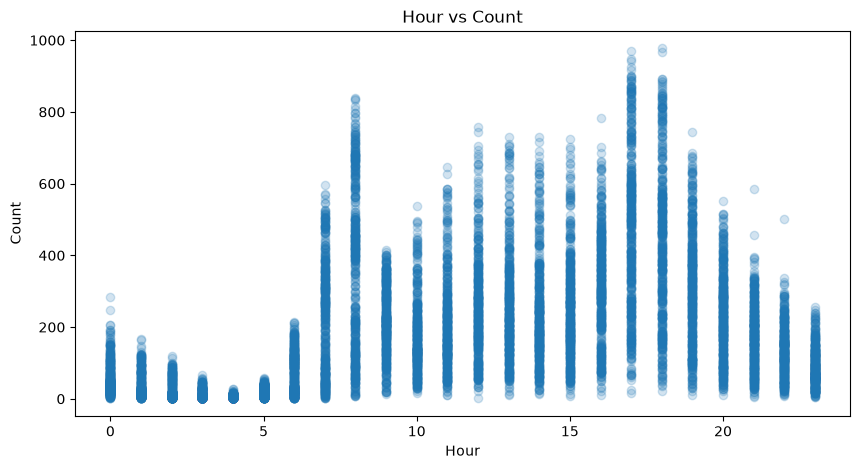

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.scatter(df["hour"], df["count"], alpha=0.2)
plt.xlabel("Hour")
plt.ylabel("Count")
plt.title("Hour vs Count")
plt.show()

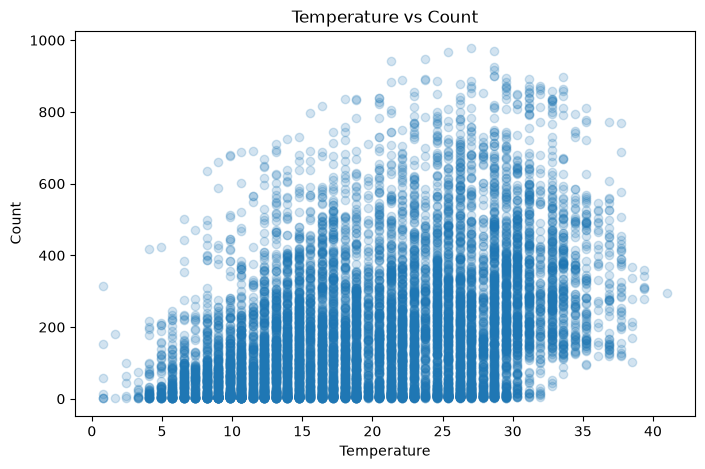

In [9]:
plt.figure(figsize=(8, 5))
plt.scatter(df["temp"], df["count"], alpha=0.2)
plt.xlabel("Temperature")
plt.ylabel("Count")
plt.title("Temperature vs Count")
plt.show()

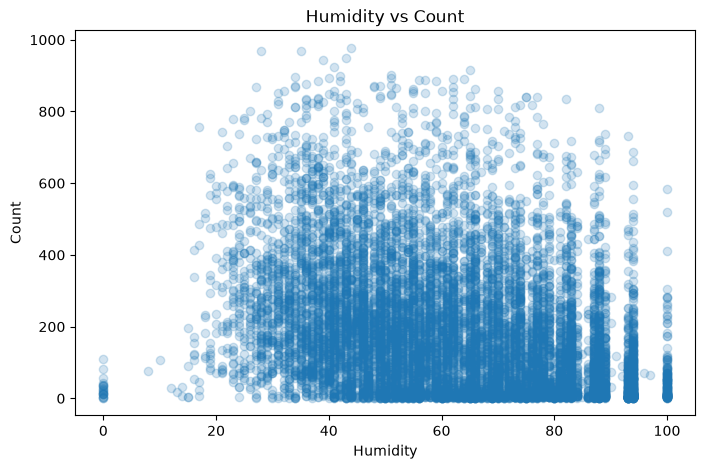

In [10]:
plt.figure(figsize=(8, 5))
plt.scatter(df["humidity"], df["count"], alpha=0.2)
plt.xlabel("Humidity")
plt.ylabel("Count")
plt.title("Humidity vs Count")
plt.show()

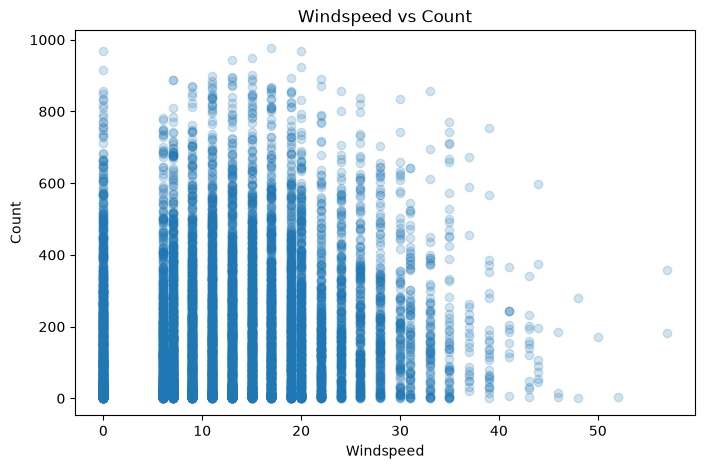

In [11]:
plt.figure(figsize=(8, 5))
plt.scatter(df["windspeed"], df["count"], alpha=0.2)
plt.xlabel("Windspeed")
plt.ylabel("Count")
plt.title("Windspeed vs Count")
plt.show()

In [12]:
hour_mean = df.groupby("hour")["count"].mean()

print(hour_mean)

hour
0      55.138462
1      33.859031
2      22.899554
3      11.757506
4       6.407240
5      19.767699
6      76.259341
7     213.116484
8     362.769231
9     221.780220
10    175.092308
11    210.674725
12    256.508772
13    257.787281
14    243.442982
15    254.298246
16    316.372807
17    468.765351
18    430.859649
19    315.278509
20    228.517544
21    173.370614
22    133.576754
23     89.508772
Name: count, dtype: float64


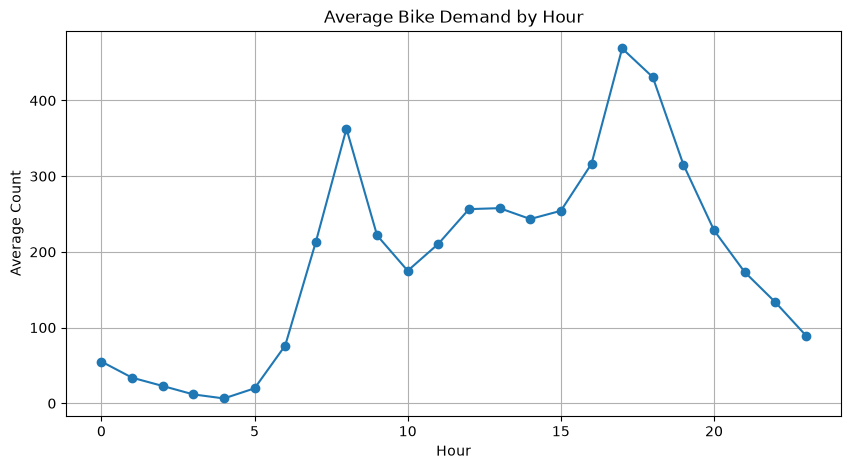

In [13]:
plt.figure(figsize=(10, 5))
plt.plot(hour_mean.index, hour_mean.values, marker="o")
plt.xlabel("Hour")
plt.ylabel("Average Count")
plt.title("Average Bike Demand by Hour")
plt.grid()
plt.show()

In [14]:
hour_workingday = df.groupby(["hour", "workingday"])["count"].mean().unstack()

print(hour_workingday)

workingday           0           1
hour                              
0            94.489655   36.732258
1            71.910345   16.003236
2            53.748252    8.436066
3            25.534722    4.892734
4             8.544828    5.363636
5             9.373239   24.529032
6            19.993103  102.577419
7            47.268966  290.690323
8           112.255172  479.945161
9           177.924138  242.293548
10          263.806897  133.596774
11          325.386207  157.019355
12          379.110345  199.347267
13          387.820690  197.160772
14          378.731034  180.366559
15          373.703448  198.627010
16          367.648276  292.466238
17          339.124138  529.209003
18          292.248276  495.485531
19          242.344828  349.282958
20          183.806897  249.363344
21          148.737931  184.855305
22          123.351724  138.344051
23           90.606897   88.996785


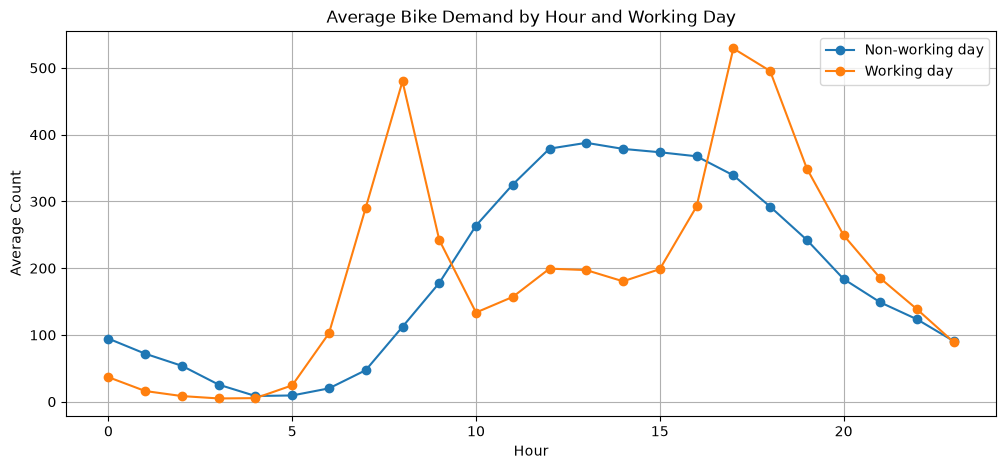

In [15]:
plt.figure(figsize=(12, 5))

plt.plot(
    hour_workingday.index,
    hour_workingday[0],
    marker="o",
    label="Non-working day"
)

plt.plot(
    hour_workingday.index,
    hour_workingday[1],
    marker="o",
    label="Working day"
)

plt.xlabel("Hour")
plt.ylabel("Average Count")
plt.title("Average Bike Demand by Hour and Working Day")
plt.legend()
plt.grid()
plt.show()

In [16]:
season_mean = df.groupby("season")["count"].mean()

print(season_mean)

season
1    116.343261
2    215.251372
3    234.417124
4    198.988296
Name: count, dtype: float64


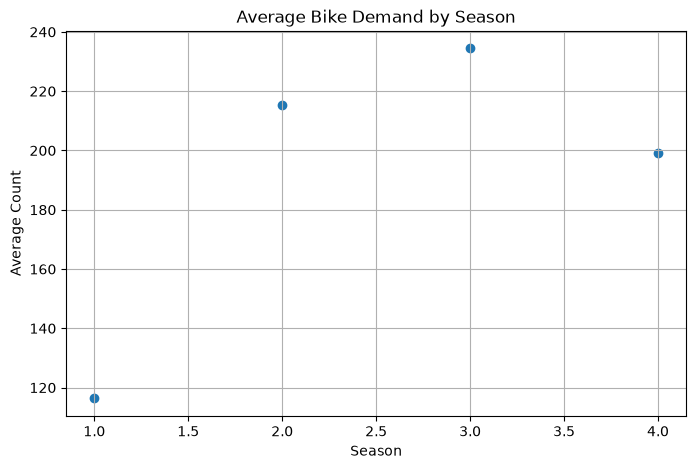

In [17]:
plt.figure(figsize=(8, 5))

plt.scatter(
    season_mean.index,
    season_mean.values
)

plt.xlabel("Season")
plt.ylabel("Average Count")
plt.title("Average Bike Demand by Season")
plt.grid()
plt.show()

In [18]:
weather_mean = df.groupby("weather")["count"].mean()

print(weather_mean)

weather
1    205.236791
2    178.955540
3    118.846333
4    164.000000
Name: count, dtype: float64


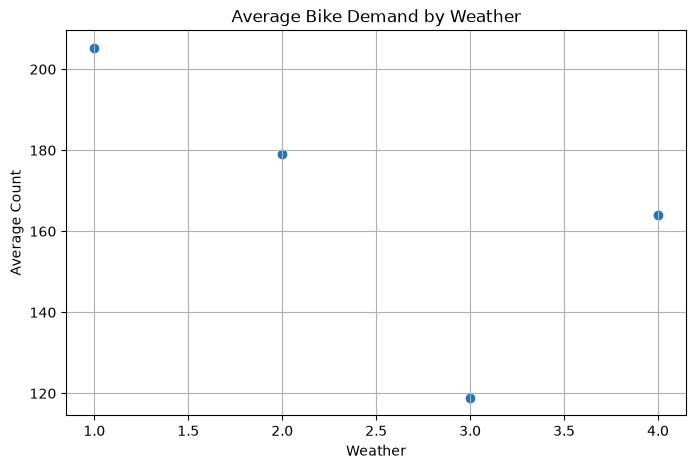

In [19]:
plt.figure(figsize=(8, 5))

plt.scatter(
    weather_mean.index,
    weather_mean.values
)

plt.xlabel("Weather")
plt.ylabel("Average Count")
plt.title("Average Bike Demand by Weather")
plt.grid()
plt.show()

In [20]:
df["datetime"] = pd.to_datetime(df["datetime"])

df["hour"] = df["datetime"].dt.hour
df["dayofweek"] = df["datetime"].dt.dayofweek
df["month"] = df["datetime"].dt.month
df["year"] = df["datetime"].dt.year

In [21]:
print(df[["temp", "humidity", "windspeed", "count"]].corr()["count"])

temp         0.394454
humidity    -0.317371
windspeed    0.101369
count        1.000000
Name: count, dtype: float64


In [22]:
df["datetime"] = pd.to_datetime(df["datetime"])

df["hour"] = df["datetime"].dt.hour
df["dayofweek"] = df["datetime"].dt.dayofweek
df["month"] = df["datetime"].dt.month
df["year"] = df["datetime"].dt.year

In [23]:
df["rush_hour"] = df["hour"].isin([7, 8, 9, 16, 17, 18, 19]).astype(int)

In [24]:
df["working_hour"] = (
    (df["workingday"] == 1) &
    (df["hour"].isin([7, 8, 9, 16, 17, 18, 19]))
).astype(int)

In [25]:
df = df.drop(columns=["datetime"])

In [26]:
df = df.drop(columns=["casual", "registered"])

In [27]:
from sklearn.model_selection import train_test_split

x = df.drop(columns=["count"])
y = df["count"]

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)

print(x_train.shape)
print(x_test.shape)

(8708, 14)
(2178, 14)


In [28]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [29]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor

knn = KNeighborsRegressor(n_neighbors=5)

svr = SVR(kernel="rbf")

rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

In [30]:
knn.fit(x_train_scaled, y_train)

svr.fit(x_train_scaled, y_train)

rf.fit(x_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [31]:
knn_pred = knn.predict(x_test_scaled)

svr_pred = svr.predict(x_test_scaled)

rf_pred = rf.predict(x_test)

In [32]:
import numpy as np
from sklearn.metrics import root_mean_squared_log_error

knn_pred = np.maximum(knn_pred, 0)
svr_pred = np.maximum(svr_pred, 0)
rf_pred = np.maximum(rf_pred, 0)

print("KNN RMSLE:", root_mean_squared_log_error(y_test, knn_pred))
print("SVR RMSLE:", root_mean_squared_log_error(y_test, svr_pred))
print("Random Forest RMSLE:", root_mean_squared_log_error(y_test, rf_pred))

KNN RMSLE: 0.737423920811352
SVR RMSLE: 0.9718564445303062
Random Forest RMSLE: 0.3265553480065224


In [33]:
test = pd.read_csv("test.csv")


In [34]:
test["datetime"] = pd.to_datetime(test["datetime"])

test["hour"] = test["datetime"].dt.hour
test["dayofweek"] = test["datetime"].dt.dayofweek
test["month"] = test["datetime"].dt.month
test["year"] = test["datetime"].dt.year

test["rush_hour"] = test["hour"].isin(
    [7, 8, 9, 16, 17, 18, 19]
).astype(int)

test["working_hour"] = (
    (test["workingday"] == 1) &
    (test["hour"].isin([7, 8, 9, 16, 17, 18, 19]))
).astype(int)

test = test.drop(columns=["datetime"])

In [35]:
print(test.columns)
print(x.columns)

Index(['season', 'holiday', 'workingday', 'weather', 'temp', 'atemp',
       'humidity', 'windspeed', 'hour', 'dayofweek', 'month', 'year',
       'rush_hour', 'working_hour'],
      dtype='str')
Index(['season', 'holiday', 'workingday', 'weather', 'temp', 'atemp',
       'humidity', 'windspeed', 'hour', 'dayofweek', 'month', 'year',
       'rush_hour', 'working_hour'],
      dtype='str')


In [36]:
rf.fit(x, y)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [37]:
test_pred = rf.predict(test)

In [38]:
test_pred = np.maximum(test_pred, 0)

In [41]:
test_raw = pd.read_csv("test.csv")

output = pd.DataFrame({
    "datetime": test_raw["datetime"],
    "count": test_pred
})

output.to_csv("output.csv", index=False)

print(output.head())
print(output.shape)

              datetime   count
0  2011-01-20 00:00:00  11.030
1  2011-01-20 01:00:00   5.115
2  2011-01-20 02:00:00   4.175
3  2011-01-20 03:00:00   3.630
4  2011-01-20 04:00:00   3.055
(6493, 2)
